In [1]:
import torch
import torch.nn as nn
import math

In [2]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
        self.label = label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
            print(" add backward ", self.grad, other.grad, out )
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            print(" mul backward ", self.grad, other.grad, out )
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
          self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
          print(" exp backward ", self.grad, out )
        out._backward = _backward
        
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
            print(" pow backward ", self.grad, out, self.data, other, out.grad )
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    # sigmoid activation function
    def sigmoid(self):
        x = self.data
        t = 1/(1+(math.exp(-x)))
        out = Value(t, (self, ), 'sigmoid')
        
        def _backward():
            f = 1/(1+(math.exp(-x)))
            self.grad += (f*(1 - f)) * out.grad
            print(" sigmoid backward ", f, self.grad, out )
        out._backward = _backward
        return out

    
    def log(self):
        # natural logarithm ln(x)
        if self.data <= 0:
            raise ValueError("log(x) requires x > 0")
    
        out = Value(math.log(self.data), (self,), 'log')
    
        def _backward():
            # d/dx log(x) = 1/x
            self.grad += (1.0 / self.data) * out.grad
            print(" log backward ", self.grad, out )
    
        out._backward = _backward
        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                print( "v ", v)
                visited.add(v)
                for child in v._prev:
                    print( "child ", child)
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [3]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

v  Value(data=4.0, grad=0)
child  Value(data=-6.0, grad=0)
v  Value(data=-6.0, grad=0)
child  Value(data=-3.0, grad=0)
v  Value(data=-3.0, grad=0)
child  Value(data=2.0, grad=0)
v  Value(data=2.0, grad=0)
child  Value(data=10.0, grad=0)
v  Value(data=10.0, grad=0)
 add backward  1 1 Value(data=4.0, grad=1)
 mul backward  -3.0 2.0 Value(data=-6.0, grad=1)


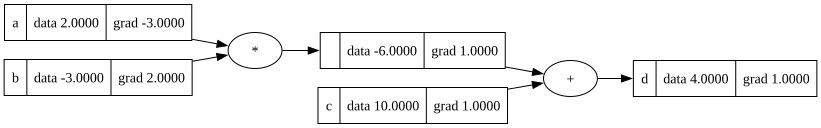

In [4]:
# -------------------------------------------------
# micrograd graph for d = a*b + c
# -------------------------------------------------
a = Value(2.0); a.label = "a"
b = Value(-3.0); b.label = "b"
c = Value(10.0); c.label = "c"

d = a * b + c
d.label = "d"

d.backward()
draw_dot(d)

In [5]:
# https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#differentiation-in-autograd

In [6]:
x00 = Value(2.0, label='x00')
x01 = Value(3.0, label='x01')

v  Value(data=35.0, grad=0)
child  Value(data=27.0, grad=0)
v  Value(data=27.0, grad=0)
child  Value(data=3.0, grad=0)
v  Value(data=3.0, grad=0)
child  Value(data=8.0, grad=0)
v  Value(data=8.0, grad=0)
child  Value(data=2.0, grad=0)
v  Value(data=2.0, grad=0)
 add backward  1 1 Value(data=35.0, grad=1)
 pow backward  12.0 Value(data=8.0, grad=1) 2.0 3 1
 pow backward  27.0 Value(data=27.0, grad=1) 3.0 3 1


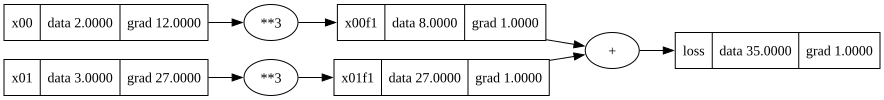

In [8]:
x00f1 = x00 ** 3; x00f1.label = 'x00f1'
x01f1 = x01 ** 3; x01f1.label = 'x01f1'

loss = x00f1 + x01f1; loss.label = 'loss'

loss.backward()

x00 -= 0.01 * x00.grad
x01 -= 0.01 * x01.grad

draw_dot(loss)

In [9]:
# a = torch.tensor([2., 3.], requires_grad=True)
# Q = a**3
# loss = Q.sum()

In [10]:
3 ** 3 # forward x01f1

27

In [11]:
2 ** 3 # forward 0x00f1

8

In [12]:
3 * 3.0 ** (3 - 1) # grad for x01 

27.0

In [13]:
3 * 2.0 ** (3 - 1) # grad for x00 

12.0

In [14]:
(27 + 8) # loss

35

In [15]:
# formula to calc grad x00
# n * X ** n - 1

In [16]:
# learning rate
lr = 0.01

In [17]:
# x00 params update

In [18]:
2.0 - (lr * 12.0)

1.88

In [19]:
# ok, I have new data value

In [20]:
1.88 ** 3

6.644671999999999

In [21]:
# now I have new x0f1 data 

In [22]:
3 * 1.88 ** (3 - 1) # grad for x00 

10.6032

In [23]:
# new grad

In [24]:
# pytorch version

In [45]:
a = torch.tensor([2., 3.], requires_grad=True)

In [47]:
#b = torch.tensor([6., 4.], requires_grad=True)
Q1 = a ** 3
print(a)
print(a.grad)
print(" -- Q1 --" )
print(Q1)
loss = Q1.sum()
print( " loss " , loss)
a.grad = None
loss.backward()
print(a.grad, a.data)
a.data += -0.01 * a.grad

tensor([1.8800, 2.7300], requires_grad=True)
tensor([12., 27.])
 -- Q1 --
tensor([ 6.6447, 20.3464], grad_fn=<PowBackward0>)
 loss  tensor(26.9911, grad_fn=<SumBackward0>)
tensor([10.6032, 22.3587]) tensor([1.8800, 2.7300])


In [27]:
# some tests

In [31]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

In [41]:
xs = torch.arange(-5,5,1)

In [42]:
def q_fun(x):
    return x ** 3

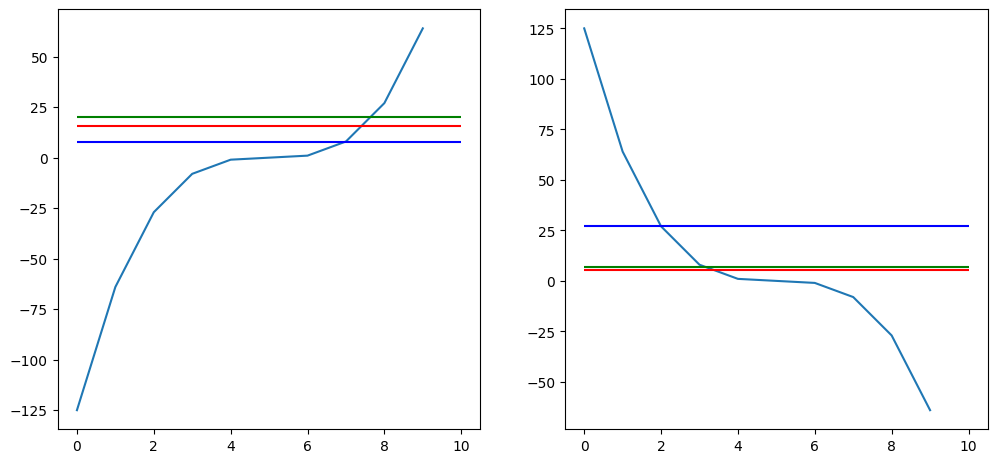

In [43]:
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.plot(q_fun(xs))
#12.4541
X_MAX = 10.0
plt.hlines(y=15.7456, xmin=0.0, xmax=X_MAX, color='r')
plt.hlines(y=20.3464, xmin=0.0, xmax=X_MAX, color='g')
plt.hlines(y=8.0000, xmin=0.0, xmax=X_MAX, color='b')
plt.subplot(2, 2, 2)
plt.plot(q_fun(-xs))
#4.7379
plt.hlines(y=5.5826, xmin=0.0, xmax=X_MAX, color='r')
plt.hlines(y=6.6447, xmin=0.0, xmax=X_MAX, color='g')
plt.hlines(y=27.0000, xmin=0.0, xmax=X_MAX, color='b')
plt.show()